# NeuralPOD-DeepONet


In [ ]:
import os, sys, pathlib
import numpy as np
import torch
import matplotlib.pyplot as plt

sys.path.insert(0, str(pathlib.Path("..").resolve()))
from utils.datasets import load
from models.regime_basis import FourierRegimeBasis
from models.fourier_neural_pod import FourierNeuralPODTrainer, FourierNeuralPODConfig
from models.pod_deeponet import BranchNet
from models.neural_pod_deeponet import NeuralPODDeepONet, NeuralPODDeepONetConfig, NeuralPODDeepONetTrainer

if torch.backends.mps.is_available():   DEVICE = 'mps'
elif torch.cuda.is_available():         DEVICE = 'cuda'
else:                                   DEVICE = 'cpu'

# path to DaRUS-downloaded HDF5 files on the server
DATA_DIR = os.path.expanduser("~/data/1D/Burgers/Train")

def rel_l2(true, pred):
    return np.linalg.norm(true - pred, axis=1) / np.linalg.norm(true, axis=1)

**Problem.** Given initial condition $u_0(x) = u(x, 0)$, approximate the solution operator
$\mathcal{G}: u_0 \mapsto u(\cdot, \cdot)$ for a time-dependent PDE on $x \in \Omega$, $t \in [0, T]$.

NeuralPOD-DeepONet replaces the linear POD basis with a nonlinear Fourier basis,
retaining the two-phase training structure of POD-DeepONet (Lu et al., 2022).


#### Phase 1: Fourier Neural POD


Let $\{u^n\}_{n=1}^N$ be training trajectories, each flattened to $\mathbf{s}^n \in \mathbb{R}^{N_t N_x}$.
The spatiotemporal coordinate of point $j$ is $\mathbf{c}_j = (x_j, t_j) \in \mathbb{R}^2$.

The field is approximated as a sum of $K$ separable modes:
$$\mathbf{s}^n \approx \boldsymbol{\mu}(\mathbf{c}) + \sum_{k=1}^K \lambda_k^n \, \boldsymbol{\phi}_k(\mathbf{c})$$

where:
- $\boldsymbol{\mu}: \mathbb{R}^2 \to \mathbb{R}$ is a neural mean field, trained first on the empirical mean
- $\boldsymbol{\phi}_k: \mathbb{R}^2 \to \mathbb{R}$ is the $k$-th spatial mode, parameterized via Random Fourier Features:
$$\boldsymbol{\phi}_k(\mathbf{c}) = \mathrm{MLP}\bigl([\sin(2\pi B\mathbf{c}),\, \cos(2\pi B\mathbf{c})]\bigr), \quad B \in \mathbb{R}^{F \times 2} \text{ fixed random}$$
- $\lambda_k^n \in \mathbb{R}$ is a scalar coefficient — one per trajectory per mode

Modes are extracted **greedily**: each $(\boldsymbol{\phi}_k, \{\lambda_k^n\})$ is trained to minimize the weighted residual
$$\mathcal{L}_k = \sum_{n=1}^N \gamma_n \sum_j w_j \bigl(\lambda_k^n \, \phi_k(\mathbf{c}_j) - r_j^n\bigr)^2$$
where $\mathbf{r}^n$ is the residual after subtracting the previous $k{-}1$ modes.
After training mode $k$, its parameters are frozen and the residual is deflated.


#### Phase 2: Branch Network


After Phase 1, the coefficient matrix $\Lambda \in \mathbb{R}^{N \times K}$ with $\Lambda_{nk} = \lambda_k^n$
encodes how each training trajectory projects onto the learned modes.

A branch network $\mathcal{B}_\theta: \mathbb{R}^m \to \mathbb{R}^K$ is trained to predict
these coefficients from the initial condition sampled at $m$ sensor points:
$$\hat{\boldsymbol{\lambda}}^n = \mathcal{B}_\theta\bigl(u_0^n(x_1), \ldots, u_0^n(x_m)\bigr)$$

Training minimizes MSE against Phase 1 coefficients:
$$\mathcal{L}(\theta) = \frac{1}{N} \sum_{n=1}^N \bigl\|\mathcal{B}_\theta(u_0^n) - \boldsymbol{\lambda}^n\bigr\|_2^2$$

The mode networks $\boldsymbol{\phi}_k$ and mean $\boldsymbol{\mu}$ are not updated in this phase.

---

#### Prediction

For a new initial condition $u_0^*$, the full spatiotemporal field is:
$$\hat{u}(\mathbf{c}) = \boldsymbol{\mu}(\mathbf{c}) + \sum_{k=1}^K \bigl[\mathcal{B}_\theta(u_0^*)\bigr]_k \, \boldsymbol{\phi}_k(\mathbf{c})$$

Unlike POD-DeepONet, the modes are not stored as fixed vectors — they are evaluated
by forward passes through $\boldsymbol{\phi}_k$ at query coordinates $\mathbf{c}$.
The result is reshaped from $\mathbb{R}^{N_t N_x}$ to $(N_t, N_x)$.


In [ ]:
path   = os.path.join(DATA_DIR, "1D_Burgers_Sols_Nu0.4.hdf5")
data   = load("Burgers_Nu0.4", path=path)
tensor = data["tensor"]                # (N_total, Nt, Nx) — 3D from DaRUS
if tensor.ndim == 4:
    tensor = tensor[..., 0]
x_np   = data["x-coordinate"]         # (Nx,)
t_np   = data["t-coordinate"]         # may be longer than Nt

N_total, Nt, Nx = tensor.shape
t_np = t_np[:Nt]                      # clip to actual number of time steps
print(f"N_total={N_total}, Nt={Nt}, Nx={Nx}")

In [3]:
N_train = 2500
N_test  = 500
tensor_train = tensor[:N_train]
tensor_test  = tensor[N_train:N_train + N_test]

In [ ]:
# flattened spatiotemporal trajectories — stay on CPU for trajectory batching
s_traj   = torch.tensor(tensor_train.reshape(N_train, -1), dtype=torch.float32)   # (N_train, Nt*Nx)
u0_train = torch.tensor(tensor_train[:, 0, :], dtype=torch.float32).to(DEVICE)    # (N_train, Nx)
u0_test  = torch.tensor(tensor_test[:, 0, :],  dtype=torch.float32).to(DEVICE)    # (N_test, Nx)

# (x, t) coordinate pairs — col 0: x, col 1: t
x_grid = torch.tensor(x_np, dtype=torch.float32)
t_grid = torch.tensor(t_np, dtype=torch.float32)
tt, xx = torch.meshgrid(t_grid, x_grid, indexing='ij')                    # (Nt, Nx)
x_flat = torch.stack([xx.flatten(), tt.flatten()], dim=1).to(DEVICE)      # (Nt*Nx, 2)

sensor_stride = 1
m = len(range(0, Nx, sensor_stride))
print(f"s_traj: {tuple(s_traj.shape)}, x_flat: {tuple(x_flat.shape)}, m={m}")

In [5]:
w     = torch.ones(Nt * Nx, dtype=torch.float32).to(DEVICE) / (Nt * Nx)
basis = FourierRegimeBasis(d_x=2, M=N_train, quad_weights=w,
                           hidden_dim=128, num_frequencies=64).to(DEVICE)

cfg_pod     = FourierNeuralPODConfig(max_modes=32, n_epochs_mean=300, n_epochs_mode=85)
trainer_pod = FourierNeuralPODTrainer(basis, cfg_pod)
trainer_pod.train(s_traj, x_flat, t= None)

Fourier NeuralPOD | N=2500, Ny=25856 | max_modes=32


mean:   0%|          | 0/300 [00:00<?, ?it/s]

mode 1:   0%|          | 0/85 [00:00<?, ?it/s]

  mode 1: weighted_res=1.5893e-02


mode 2:   0%|          | 0/85 [00:00<?, ?it/s]

...

mode 31:   0%|          | 0/85 [00:00<?, ?it/s]

  mode 31: weighted_res=5.4926e-03


mode 32:   0%|          | 0/85 [00:00<?, ?it/s]

  mode 32: weighted_res=5.4819e-03
  done: 32 modes



TrainHistory(mean_loss=[3.510612199841724e-07, 1.931416384691973e-08, 1.655351889830552e-08, 1.2965473202215131e-08, 1.1556557149632835e-08, 1.0437154020861075e-08, 8.277453818357359e-09, 7.55511500280773e-09, 7.460848559971302e-09, 7.241214487078778e-09, 6.910188054740882e-09, 6.425643289043818e-09, 6.1939695987734294e-09, 5.902597792003341e-09, 5.727425623428616e-09], mode_losses=[[0.0004514454895518674, 1.9710458012482242e-05, 1.9693529159865485e-05, 1.9677421945099996e-05, 1.9669599851675968e-05], [1.9961235087838767e-05, 1.6128668326671523e-05, 1.5760446640376476e-05, 1.5702776442993233e-05, 1.5691742266701096e-05], [1.604820025445721e-05, 1.568807752027178e-05, 1.2363776329549984e-05, 1.207441165619646e-05, 1.2046354261021388e-05], [1.2579692535177631e-05, 1.2032662706957073e-05, 1.0601694652781463e-05, 1.0439313227001693e-05, 1.0411906514221274e-05], [1.0758470135850093e-05, 1.040292267329377e-05, 1.0098185786902004e-05, 9.893998975654216e-06, 9.816627203580277e-06], [1.01978987

In [6]:
K      = basis.num_modes
branch = BranchNet(m=m, P=K, hidden_dim=128, n_layers=4).to(DEVICE)
model  = NeuralPODDeepONet(basis, branch).to(DEVICE)

cfg     = NeuralPODDeepONetConfig(n_epochs=150000, batch_size=256, sensor_stride=sensor_stride)
trainer = NeuralPODDeepONetTrainer(model, cfg)
history = trainer.train(u0_train)


NeuralPOD-DeepONet Phase 2 | N=2500, m=101, K=32
  epoch    0 | coeff_mse=5.4015e-01
  epoch   50 | coeff_mse=4.4841e-02
  epoch  100 | coeff_mse=3.9357e-02
  epoch  150 | coeff_mse=3.2948e-02
  epoch  200 | coeff_mse=2.9841e-02
  epoch  250 | coeff_mse=2.7754e-02
  epoch  300 | coeff_mse=2.6835e-02
  epoch  350 | coeff_mse=2.4889e-02
  epoch  400 | coeff_mse=2.3231e-02
  epoch  450 | coeff_mse=2.2487e-02
  epoch  500 | coeff_mse=2.1064e-02
  epoch  550 | coeff_mse=2.0235e-02
  epoch  600 | coeff_mse=1.9817e-02
  epoch  650 | coeff_mse=1.9113e-02
  epoch  700 | coeff_mse=1.8360e-02
  epoch  750 | coeff_mse=1.7760e-02
  epoch  800 | coeff_mse=1.7713e-02
  epoch  850 | coeff_mse=1.6556e-02
  epoch  900 | coeff_mse=1.6306e-02
  epoch  950 | coeff_mse=1.5827e-02
  epoch 1000 | coeff_mse=1.5296e-02
  epoch 1050 | coeff_mse=1.4681e-02
  epoch 1100 | coeff_mse=1.4324e-02
  epoch 1150 | coeff_mse=1.3994e-02
  epoch 1200 | coeff_mse=1.3622e-02
  epoch 1250 | coeff_mse=1.3332e-02
  epoch 1300 | 

In [7]:
true_train = s_traj.cpu().numpy()
pred_train = trainer.predict(u0_train, x_flat).cpu().numpy()

true_test = tensor_test.reshape(N_test, -1)
pred_test = trainer.predict(u0_test, x_flat).cpu().numpy()

err_train = rel_l2(true_train, pred_train)
err_test  = rel_l2(true_test,  pred_test)

print(f"Train | mean rel L2: {err_train.mean():.4f}")
print(f"Test  | mean rel L2: {err_test.mean():.4f}")

Train | mean rel L2: 0.2063
Test  | mean rel L2: 0.2701


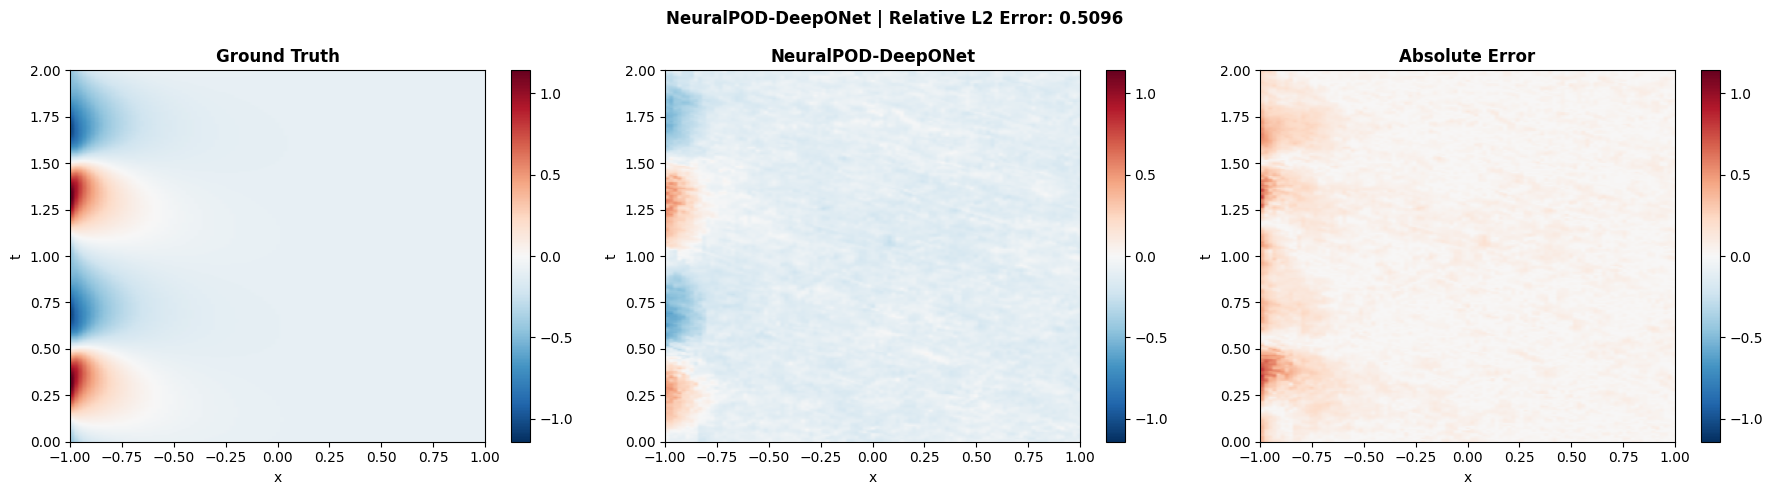

In [8]:
traj_idx = 5

pred = trainer.predict(u0_test[traj_idx:traj_idx+1], x_flat).reshape(Nt, Nx)
true = torch.tensor(tensor_test[traj_idx])

pred_np = pred.cpu().numpy()
true_np = true.cpu().numpy()
err_np  = np.abs(true_np - pred_np)
vmax    = np.abs(true_np).max()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, arr, title in zip(axes, [true_np, pred_np, err_np],
                           ["Ground Truth", "NeuralPOD-DeepONet", "Absolute Error"]):
    im = ax.imshow(arr, aspect='auto', origin='lower', cmap='RdBu_r',
                   extent=[x_np.min(), x_np.max(), t_np.min(), t_np.max()],
                   vmin=-vmax, vmax=vmax)
    ax.set_xlabel('x'); ax.set_ylabel('t'); ax.set_title(title, fontweight='bold')
    plt.colorbar(im, ax=ax)

rel_err = np.linalg.norm(true_np - pred_np) / np.linalg.norm(true_np)
fig.suptitle(f"NeuralPOD-DeepONet | Relative L2 Error: {rel_err:.4f}", fontweight='bold')
plt.tight_layout()
plt.show()